# 📋 v2 수정 사항 요약

원본(`US_final_predict.ipynb`) 대비 정확도 개선을 위해 수정한 부분:

1. **앙상블 가중치 자동 최적화** — 하드코딩된 1:1:1 가중치 대신 `scipy.optimize`로 Validation AUC를 최대화하는 가중치를 탐색 (Cell 11)
2. **PatchTST 조기종료 버그 수정** — `patience` 4→20 (LR 워밍업 10epoch 고려) (Cell 10)
3. **PatchTST Optuna 탐색 강화** — `epochs 15→30`, trial 12 (Cell 9)
4. **예측 호라이즌 조정** — `PRED_DAYS 1→3` (Cell 3)
5. **피어 종목 풀링** — 반도체 피어(AMD, AVGO, QCOM, TSM, MU) 확장 (Cell 9.5)
6. **워크포워드 피처 선택** (Cell 6)

## 🚀 v3 정확도 개선 (누출 제거 + 딥러닝 강화)
- **데이터 정합성**: `auto_adjust=True` 수정주가, `bfill`(미래정보 역채움) 제거, 실전 예측 `for_predict`로 최신일 보존, Optuna 탐색에서 테스트 구간 제외
- **[A] PatchTST 피어 시퀀스 풀링** (Cell 9.5·10): 트리뿐 아니라 딥러닝도 피어 시퀀스로 학습 → 단일 종목 데이터 굶주림 해소(가장 큰 NN 병목)
- **[B] Purged Walk-Forward CV** (Cell 6.5·9): 라벨이 미래 `PRED_DAYS`일을 보므로 겹치는 구간을 퍼지 → train↔test 정보 겹침(비-IID) 누출 제거
- **[B] 표본 가중치**(uniqueness×magnitude, Cell 6.5·10): 겹치는 라벨을 독립표본처럼 보정 + 수익 기회가 큰 표본에 비중. 세 모델 모두 반영
- **평가 강화**: 거래비용 반영 백테스트 + Sharpe/Sortino/MDD/Calmar + 상승/하락 레짐 분해 (Cell 11), 트리 확률 캘리브레이션, Optuna/시드 고정

> ⚠️ **성능 기대치**: 단일 종목 3일 방향성은 신호가 약해 AUC 0.55→0.58~0.60 수준이 현실적 목표입니다. 풀링으로 학습량이 ~6배 늘어 학습 시간도 증가합니다. Cell 9의 **"Purged WF CV 평균 AUC"**, Cell 11의 **"진짜 Test AUC"**를 개선 판단 지표로 보세요.

⚠️ **주의**: 이 파일을 Jupyter에서 열기 전 기존 `US_final_predict.ipynb` 탭은 닫아두세요(자동저장 덮어쓰기 방지).

In [69]:
%pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu128 --no-cache-dir
%pip install -U FinanceDataReader 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings, pickle
warnings.filterwarnings('ignore')


import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


# 운영체제별 폰트 예외 처리 (Windows / Linux)
try:
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    font_prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = font_prop.get_name()
except:
    plt.rcParams['font.family'] = 'Malgun Gothic'  # 로컬 윈도우 기본 폰트
plt.rcParams['axes.unicode_minus'] = False


from pykrx import stock
import yfinance as yf
from datetime import datetime, timedelta


from ta.momentum import RSIIndicator, StochasticOscillator
from ta.trend import MACD, EMAIndicator, SMAIndicator
from ta.volatility import BollingerBands, AverageTrueRange
from ta.volume import OnBalanceVolumeIndicator


from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, f1_score, roc_curve)
from sklearn.utils.class_weight import compute_class_weight
import lightgbm as lgb


# 🔥 PyTorch 핵심 컴포넌트 임포트
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader


# 🔥 로컬 GPU(RTX 5060 Ti) 장치 고정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ PyTorch    : {torch.__version__}')
print(f'✅ LightGBM   : {lgb.__version__}')
print(f'✅ Optuna     : {optuna.__version__}')
print(f'✅ GPU Device : {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"})')


# =====================================================================

Looking in indexes: https://download.pytorch.org/whl/nightly/cu128
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
✅ PyTorch    : 2.12.0.dev20260408+cu128
✅ LightGBM   : 4.6.0
✅ Optuna     : 4.9.0
✅ GPU Device : cuda (NVIDIA GeForce RTX 5060 Ti)


ERROR: Could not find a version that satisfies the requirement FinanceDataReader (from versions: none)
ERROR: No matching distribution found for FinanceDataReader

[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:
# =====================================================================
# ⚙️ Cell 3: 설정값 지정 (미장 전용)
# =====================================================================
import random
import datetime
import time
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import yfinance as yf
import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler          # ✅ 재현성: 샘플러 시드 고정용
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV   # ✅ #15 확률 캘리브레이션
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, roc_curve
from ta.momentum import RSIIndicator
from ta.trend import SMAIndicator, EMAIndicator, MACD
from ta.volatility import AverageTrueRange, BollingerBands
from ta.volume import OnBalanceVolumeIndicator

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# 🎯 타겟 종목
TICKER     = 'AAPL'
START_DATE = '2015-01-01'
END_DATE   = datetime.datetime.today().strftime('%Y-%m-%d')

SEQ_LEN    = 60
# ✅ [개선] 1일→3일: 1일 방향성은 노이즈가 너무 커서 AUC가 랜덤 수준(~0.51~0.55)에 머물러 있었음.
#    호라이즌을 늘리면 기술적 지표 대비 노이즈 비율이 개선되는 경우가 많음.
#    되돌리려면 이 값만 1로 바꾸면 됨 (다른 코드 수정 불필요)
PRED_DAYS  = 3
EPOCHS     = 200
TEST_RATIO = 0.15
VAL_RATIO  = 0.15
LSTM_UNITS = [64, 32]

# ✅ 매매 룰 / 백테스트 파라미터
HOLDING_DAYS     = 5       # 진입 후 강제 홀딩 영업일
TRANSACTION_COST = 0.001   # ✅ #4 편도 거래비용 0.1% (진입·청산 시 각각 차감)


# ✅ threshold 후보 (탐색용) — PRED_DAYS=3에 맞춰 스케일 조정 (대략 sqrt(3)배)
THRESHOLD_CANDIDATES = [0.003, 0.005, 0.008, 0.012, 0.017, 0.025]

# ✅ 가중치 초기값 (Cell 11에서 Validation AUC 기준으로 자동 최적화되어 덮어씀)
W_LSTM = 0.33
W_LGBM = 0.33
W_RF   = 0.34

# ✅ [개선] 피어 종목 풀링 — 트리 모델(LGBM/RF) 학습 데이터 확장용
#    피처가 대부분 수익률·비율·RSI 등 스케일 불변 지표라 종목 간 풀링이 가능함
#    (NVDA 한 종목 ~2900일치 데이터만으로는 특정 구간에 과적합될 위험이 있음)
PEER_TICKERS = ['AMD', 'AVGO', 'QCOM', 'TSM', 'MU']

# PatchTST 하이퍼파라미터
PATCH_LEN = 10   # 패치 하나의 길이 (60일 / 10일 = 6개 패치)
D_MODEL   = 64   # Transformer 임베딩 차원
N_HEADS   = 4    # Multi-head Attention 헤드 수
N_LAYERS  = 2    # Transformer 인코더 레이어 수

print(f'🔧 PatchTST 설정: PATCH_LEN={PATCH_LEN} | D_MODEL={D_MODEL} | N_HEADS={N_HEADS} | N_LAYERS={N_LAYERS}')
print(f'📌 미장 종목 티커 : {TICKER} (피어: {PEER_TICKERS})')
print(f'📅 기간            : {START_DATE} ~ {END_DATE}')
print(f'🔮 예측 타겟       : 미래 {PRED_DAYS}영업일 뒤 방향성')
print(f'🎯 Threshold 후보  : {THRESHOLD_CANDIDATES}')
print(f'💸 거래비용(편도): {TRANSACTION_COST*100:.2f}% | 홀딩: {HOLDING_DAYS}일 | SEED={SEED}')

🔧 PatchTST 설정: PATCH_LEN=10 | D_MODEL=64 | N_HEADS=4 | N_LAYERS=2
📌 미장 종목 티커 : AAPL (피어: ['AMD', 'AVGO', 'QCOM', 'TSM', 'MU'])
📅 기간            : 2015-01-01 ~ 2026-07-23
🔮 예측 타겟       : 미래 3영업일 뒤 방향성
🎯 Threshold 후보  : [0.003, 0.005, 0.008, 0.012, 0.017, 0.025]
💸 거래비용(편도): 0.10% | 홀딩: 5일 | SEED=42


In [71]:
# =====================================================================
# 📥 Cell 4 & 5: 미장 데이터 + 거시경제 융합 및 피처 엔지니어링
# =====================================================================

def fetch_us_data(ticker, start, end):
    print(f'📡 {ticker} yfinance 주가 데이터 수집 중...')
    # ✅ #8 auto_adjust=True: 분할·배당 반영 수정주가. 미지정 시 버전에 따라 결과가
    #    달라지고(재현성↓), 분할일 Return이 -90%로 잡혀 라벨/피처가 오염됨(NVDA 10:1 등).
    df = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
    df.index = pd.to_datetime(df.index)
    df.dropna(inplace=True)
    print(f'✅ {ticker} 데이터 수집 완료! ({len(df)}일치)')
    return df, ticker

def fetch_external_data(start, end):
    print('📡 글로벌 거시경제 지수 동기화 중...')
    tickers = {
        'SP500' : '^GSPC',
        'NDX'   : '^NDX',
        'VIX'   : '^VIX',
        'DXY'   : 'DX-Y.NYB',
        'OIL'   : 'CL=F',
        'TNX'   : '^TNX',
    }
    ext = pd.DataFrame()
    for name, sym in tickers.items():
        try:
            data = yf.download(sym, start=start, end=end, progress=False, auto_adjust=True)
            if isinstance(data.columns, pd.MultiIndex):
                data.columns = data.columns.get_level_values(0)
            ext[name] = data['Close']
        except Exception as e:                       # ✅ bare except → 원인 로깅
            print(f'  ⚠️ {name} 다운로드 실패: {e}')
    ext.index = pd.to_datetime(ext.index)
    return ext

def add_features(df, threshold=0.01, for_predict=False):
    """for_predict=False : 학습용 — Future_Return/Label 생성(마지막 PRED_DAYS행은 라벨이 없어 제거됨).
       for_predict=True  : 실전 예측용 — 라벨을 만들지 않아 '가장 최근 거래일'까지 보존.
                           ⚠️ 예측 경로에서 for_predict=False를 쓰면 최신 PRED_DAYS일이 잘려나가
                              사실상 며칠 전 데이터로 예측하는 버그가 됨(#1)."""
    d = df.copy()

    if 'SP500' in d.columns: d['SP500_return_1d'] = d['SP500'].pct_change().shift(1)
    if 'NDX' in d.columns:   d['NDX_return_1d']   = d['NDX'].pct_change().shift(1)
    if 'DXY' in d.columns:   d['DXY_return_1d']   = d['DXY'].pct_change().shift(1)
    if 'OIL' in d.columns:   d['OIL_return_1d']   = d['OIL'].pct_change().shift(1)
    if 'VIX' in d.columns:   d['VIX_diff_1d']     = d['VIX'].diff().shift(1)
    if 'TNX' in d.columns:   d['TNX_diff_1d']     = d['TNX'].diff().shift(1)

    d['Return'] = d['Close'].pct_change()
    for i in [2, 5, 10, 20]: d[f'Return_{i}d'] = d['Close'].pct_change(i)
    d['HL_ratio'] = (d['High'] - d['Low']) / d['Close']
    d['OC_ratio'] = (d['Close'] - d['Open']) / (d['Open'] + 1e-9)
    d['Gap'] = (d['Open'] - d['Close'].shift(1)) / (d['Close'].shift(1) + 1e-9)

    for w in [5, 10, 20, 60, 120]:
        sma = SMAIndicator(d['Close'], window=w).sma_indicator()
        d[f'SMA_{w}'] = sma
        d[f'SMA_dist_{w}'] = (d['Close'] - sma) / (sma + 1e-9)

    d['EMA_12'] = EMAIndicator(d['Close'], window=12).ema_indicator()
    d['EMA_26'] = EMAIndicator(d['Close'], window=26).ema_indicator()
    macd = MACD(d['Close'])
    d['MACD'], d['MACD_signal'], d['MACD_diff'] = macd.macd(), macd.macd_signal(), macd.macd_diff()

    for w in [7, 14, 21]: d[f'RSI_{w}'] = RSIIndicator(d['Close'], window=w).rsi()

    d['Volume_ratio'] = d['Volume'] / (d['Volume'].rolling(20).mean() + 1e-9)
    d['Vol_5d']  = d['Return'].rolling(5).std()
    d['Vol_20d'] = d['Return'].rolling(20).std()
    d['Vol_ratio'] = d['Vol_5d'] / (d['Vol_20d'] + 1e-9)

    if 'NDX_return_1d' in d.columns:
        d['TICKER_vs_NDX_1d'] = d['Return'].shift(1) - d['NDX_return_1d']

    raw_macro_cols = ['SP500', 'NDX', 'VIX', 'DXY', 'OIL', 'TNX']
    d = d.drop(columns=[col for col in raw_macro_cols if col in d.columns], errors='ignore')

    if not for_predict:
        d['Future_Return'] = (d['Close'].shift(-PRED_DAYS) - d['Close']) / d['Close']
        d['Label'] = (d['Future_Return'] > threshold).astype(int)

    d.replace([np.inf, -np.inf], np.nan, inplace=True)
    # ✅ #2 bfill 제거: 미래값 역채움(look-ahead)을 없애고 ffill만 적용.
    #    지표 워밍업(SMA_120 등)으로 생긴 앞쪽 NaN은 dropna로 제거.
    return d.ffill().dropna()

# -----------------------------------------------------------------
# 🚀 데이터 수집 및 융합
# -----------------------------------------------------------------
df_raw, stock_name = fetch_us_data(TICKER, START_DATE, END_DATE)
df_ext = fetch_external_data(START_DATE, END_DATE)
df_merged = df_raw.join(df_ext, how='left').ffill().dropna()

print(f'✅ 원본 및 거시경제 지수 데이터 병합 완료! ({len(df_merged)}일치)')

📡 AAPL yfinance 주가 데이터 수집 중...
✅ AAPL 데이터 수집 완료! (2904일치)
📡 글로벌 거시경제 지수 동기화 중...
✅ 원본 및 거시경제 지수 데이터 병합 완료! (2904일치)


In [72]:
# =====================================================================
# ⚙️ Cell 6: 전처리 함수 정의 (threshold 인자 받는 구조)
# =====================================================================

EXCLUDE_COLS = ['Label','Open','High','Low','Close','Volume',
                'SP500','NDX','VIX','DXY','OIL','TNX','Future_Return']

class WalkForwardSelector:
    """✅ [개선] 단일 RF 스냅샷 대신 여러 확장 구간(walk-forward)의 평균 중요도로 피처 선택.
    시계열에서는 한 시점의 importance가 불안정할 수 있어, 여러 구간에서 일관되게
    중요한 피처만 남기면 선택이 더 안정적이다."""
    def __init__(self, n_windows=4, random_state=42):
        self.n_windows = n_windows
        self.random_state = random_state
        self.mask_ = None

    def fit(self, X, y):
        n = len(X)
        win_size = max(n // self.n_windows, 50)
        importances = []
        for w in range(self.n_windows):
            end = min(win_size * (w + 1), n)
            if end < 50:
                continue
            rf = RandomForestClassifier(n_estimators=100, random_state=self.random_state, n_jobs=-1)
            rf.fit(X[:end], y[:end])
            importances.append(rf.feature_importances_)
        avg_imp = np.mean(importances, axis=0)
        self.mask_ = avg_imp >= avg_imp.mean()
        if self.mask_.sum() == 0:
            self.mask_[:] = True
        return self

    def transform(self, X):
        return X[:, self.mask_]

def preprocess(df_merged, threshold):
    df_feat = add_features(df_merged, threshold=threshold)

    up_ratio = df_feat['Label'].mean()
    print(f'   threshold={threshold:.3f} | 상승={up_ratio*100:.1f}% | 하락={(1-up_ratio)*100:.1f}%')

    feature_cols = [c for c in df_feat.columns if c not in EXCLUDE_COLS]
    X_raw = df_feat[feature_cols].values
    y_raw = df_feat['Label'].values

    X_raw = np.where(np.isinf(X_raw), np.nan, X_raw)
    # ✅ #2 bfill 제거 (미래값 역채움 방지). df_feat는 이미 결측이 없어 ffill만으로 충분.
    X_raw = pd.DataFrame(X_raw, columns=feature_cols).ffill().values

    n = len(X_raw)
    test_size = int(n * TEST_RATIO)
    val_size  = int(n * VAL_RATIO)
    train_size = n - test_size - val_size

    scaler = RobustScaler()
    X_tr_sc = scaler.fit_transform(X_raw[:train_size])
    X_vl_sc = scaler.transform(X_raw[train_size:train_size+val_size])
    X_te_sc = scaler.transform(X_raw[train_size+val_size:])

    y_train = y_raw[:train_size]
    y_val   = y_raw[train_size:train_size+val_size]
    y_test  = y_raw[train_size+val_size:]

    selector = WalkForwardSelector(n_windows=4, random_state=42)
    selector.fit(X_tr_sc, y_train)

    X_tr_sel = selector.transform(X_tr_sc)
    X_vl_sel = selector.transform(X_vl_sc)
    X_te_sel = selector.transform(X_te_sc)

    def make_sequences(X, y, seq_len):
        xs, ys = [], []
        for i in range(seq_len, len(X)):
            xs.append(X[i-seq_len:i])
            ys.append(y[i])
        return np.array(xs), np.array(ys)

    X_tr, y_tr = make_sequences(X_tr_sel, y_train, SEQ_LEN)
    X_vl, y_vl = make_sequences(X_vl_sel, y_val,   SEQ_LEN)
    X_te, y_te = make_sequences(X_te_sel, y_test,  SEQ_LEN)

    X_tr_flat = X_tr[:, -1, :]
    X_vl_flat = X_vl[:, -1, :]
    X_te_flat = X_te[:, -1, :]

    return (df_feat, feature_cols, scaler, selector,
            X_tr, y_tr, X_vl, y_vl, X_te, y_te,
            X_tr_flat, X_vl_flat, X_te_flat)

print('✅ 전처리 함수 정의 완료! (피처 선택: walk-forward 평균 중요도 방식)')

✅ 전처리 함수 정의 완료! (피처 선택: walk-forward 평균 중요도 방식)


In [73]:
# =====================================================================
# 🧩 Cell 6.5 [신규]: 정확도 개선용 공용 헬퍼
#   A) 시퀀스 생성  B) Purged Walk-Forward 분할 + 라벨 uniqueness·크기 가중
# =====================================================================

def make_seq(X, y, seq_len):
    """2D 피처행렬 → 3D 시퀀스. y[i]는 창의 마지막(=예측 기준) 라벨."""
    xs, ys = [], []
    for i in range(seq_len, len(X)):
        xs.append(X[i - seq_len:i])
        ys.append(y[i])
    return np.array(xs), np.array(ys)


def purged_walk_forward_splits(n, n_splits=4, horizon=1, embargo_frac=0.01):
    """✅ [B] 겹치는 라벨(look-ahead)을 막는 확장형 워크포워드 분할.
    라벨이 미래 horizon일을 보므로, 테스트 시작 직전 horizon일(+embargo)을
    학습에서 '퍼지(purge)'해 train↔test 정보 겹침을 제거한다.
    yield: (train_idx, test_idx)"""
    fold = n // (n_splits + 1)
    embargo = int(n * embargo_frac)
    for k in range(n_splits):
        test_start = fold * (k + 1)
        test_end   = min(fold * (k + 2), n)
        if test_end - test_start < 1:
            continue
        train_end = max(test_start - horizon - embargo, 0)   # purge + embargo
        train_idx = np.arange(0, train_end)
        test_idx  = np.arange(test_start, test_end)
        if len(train_idx) == 0 or len(test_idx) == 0:
            continue
        yield train_idx, test_idx


def sample_weights_uniqueness(future_returns, horizon, use_magnitude=True):
    """✅ [B/#14] 표본 가중치 = (라벨 평균 uniqueness) × (수익 크기 팩터).

    - uniqueness: 각 라벨은 [i, i+horizon) 구간을 점유. 같은 시점을 여러 라벨이
      공유(concurrency)할수록 정보가 중복되므로 1/concurrency의 평균으로 가중 축소.
      → 겹치는 라벨을 사실상 독립표본처럼 다루도록 보정(비-IID 완화).
    - magnitude: |미래수익|이 큰(=수익 기회가 큰) 표본에 더 큰 비중(상한 있는 [1,2] 팩터).
    반환: 평균≈1로 정규화된 가중치 배열."""
    fr = np.asarray(future_returns, dtype=float)
    n = len(fr)
    if n == 0:
        return np.ones(0)
    conc = np.zeros(n + horizon)
    for i in range(n):
        conc[i:i + horizon] += 1.0
    u = np.array([np.mean(1.0 / conc[i:i + horizon]) for i in range(n)])
    w = u.copy()
    if use_magnitude:
        mag = np.abs(fr)
        denom = np.quantile(mag, 0.95) + 1e-9
        w = w * (1.0 + np.clip(mag / denom, 0.0, 1.0))   # [1,2] 범위 팩터
    w = w * (n / (w.sum() + 1e-12))                       # 평균≈1 정규화
    return w

print('✅ 헬퍼 정의 완료: make_seq · purged_walk_forward_splits · sample_weights_uniqueness')

✅ 헬퍼 정의 완료: make_seq · purged_walk_forward_splits · sample_weights_uniqueness


In [74]:
# =====================================================================
# 🤖 Cell 7: PatchTST 모델 정의
# =====================================================================

class PatchEmbedding(nn.Module):
    """시계열을 패치 단위로 쪼개서 임베딩"""
    def __init__(self, n_features, patch_len, d_model, dropout=0.1):
        super().__init__()
        self.patch_len  = patch_len
        self.projection = nn.Linear(patch_len * n_features, d_model)
        self.dropout    = nn.Dropout(dropout)
        self.norm       = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: (batch, seq_len, n_features)
        B, L, F = x.shape
        n_patches = L // self.patch_len

        # 패치로 쪼개기
        x = x[:, :n_patches * self.patch_len, :]         # 딱 떨어지게 자르기
        x = x.reshape(B, n_patches, self.patch_len * F)  # (B, n_patches, patch_len*F)
        x = self.projection(x)                            # (B, n_patches, d_model)
        x = self.norm(x)
        return self.dropout(x)


class PatchTST(nn.Module):
    """PatchTST: 시계열 전용 Transformer"""
    def __init__(self, n_features, seq_len, patch_len=10,
                 d_model=64, n_heads=4, n_layers=2, dropout=0.3):
        super().__init__()
        self.patch_embedding = PatchEmbedding(n_features, patch_len, d_model, dropout)

        n_patches = seq_len // patch_len

        # Positional Encoding
        self.pos_encoding = nn.Parameter(torch.zeros(1, n_patches, d_model))
        nn.init.trunc_normal_(self.pos_encoding, std=0.02)

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model    = d_model,
            nhead      = n_heads,
            dim_feedforward = d_model * 4,
            dropout    = dropout,
            batch_first = True,
            norm_first  = True      # Pre-LN → 학습 안정성 향상
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.norm        = nn.LayerNorm(d_model)

        # 분류 헤드
        self.head = nn.Sequential(
            nn.Linear(d_model * n_patches, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # 패치 임베딩
        x = self.patch_embedding(x)           # (B, n_patches, d_model)
        x = x + self.pos_encoding             # Positional Encoding 추가
        x = self.transformer(x)               # (B, n_patches, d_model)
        x = self.norm(x)
        x = x.flatten(1)                      # (B, n_patches * d_model)
        return self.head(x)                   # (B, 1)

print('✅ PatchTST 모델 정의 완료!')
print(f'   패치 수: {SEQ_LEN // PATCH_LEN}개 ({SEQ_LEN}일 / {PATCH_LEN}일)')
print(f'   d_model={D_MODEL} | n_heads={N_HEADS} | n_layers={N_LAYERS}')

✅ PatchTST 모델 정의 완료!
   패치 수: 6개 (60일 / 10일)
   d_model=64 | n_heads=4 | n_layers=2


In [75]:
# =====================================================================
# 🏋️ Cell 8: 학습 함수 + threshold 탐색 (LightGBM + RF만 사용)
# =====================================================================

def train_pytorch_engine(model, X_train, y_train, X_val, y_val,
                         epochs, batch_size, lr, class_weight, patience=15,
                         sample_weight=None):
    """✅ [B] sample_weight 지원: 라벨 uniqueness·크기 가중을 손실에 반영.
    (None이면 기존과 동일하게 균등 가중.)"""
    X_tr_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_tr_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
    X_vl_t = torch.tensor(X_val,   dtype=torch.float32).to(device)

    if sample_weight is None:
        sw_t = torch.ones_like(y_tr_t)
    else:
        sw_t = torch.tensor(np.asarray(sample_weight), dtype=torch.float32).unsqueeze(1).to(device)

    loader    = DataLoader(TensorDataset(X_tr_t, y_tr_t, sw_t), batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)  # ✅ Adam → AdamW
    criterion = nn.BCELoss(reduction='none')

    # ✅ Warmup + CosineAnnealing 스케줄러
    warmup_epochs = 10
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return epoch / warmup_epochs
        return 0.5 * (1 + np.cos(
            np.pi * (epoch - warmup_epochs) / (epochs - warmup_epochs)
        ))
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    best_auc, patience_counter, best_state = 0.0, 0, None
    w0, w1 = class_weight[0], class_weight[1]

    for epoch in range(epochs):
        model.train()
        for bX, by, bw in loader:
            optimizer.zero_grad()
            out  = model(bX)
            # 클래스 가중 × 표본 가중(uniqueness·magnitude)
            loss = (criterion(out, by) * (by*w1 + (1-by)*w0) * bw).mean()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # ✅ Gradient Clipping
            optimizer.step()

        scheduler.step()

        model.eval()
        with torch.no_grad():
            val_out = model(X_vl_t).cpu().numpy()

        val_auc = roc_auc_score(y_val, val_out) if len(np.unique(y_val)) > 1 else 0.5

        if val_auc > best_auc:
            best_auc          = val_auc
            patience_counter  = 0
            best_state        = pickle.loads(pickle.dumps(model.state_dict()))
        else:
            patience_counter += 1
            if patience_counter >= patience: break

    if best_state: model.load_state_dict(best_state)
    return best_auc



# ✅ 1단계: threshold 탐색 (LightGBM + RF만, 빠르게)
print('🔍 1단계: Threshold 후보 탐색 중 (LightGBM + RF)...')
print('='*55)

threshold_scores = {}

for t in THRESHOLD_CANDIDATES:
    (df_feat_t, feature_cols_t, scaler_t, selector_t,
     X_tr_t, y_tr_t, X_vl_t, y_vl_t, X_te_t, y_te_t,
     X_tr_flat_t, X_vl_flat_t, X_te_flat_t) = preprocess(df_merged, threshold=t)

    up_ratio = y_tr_t.mean()
    if not (0.35 <= up_ratio <= 0.65):
        print(f'   threshold={t:.3f} → ⚠️ 스킵 (불균형 심함)\n')
        continue

    # LightGBM 빠른 학습
    lgb_temp = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05,
        class_weight='balanced', random_state=SEED, verbose=-1
    )
    lgb_temp.fit(X_tr_flat_t, y_tr_t,
                 eval_set=[(X_vl_flat_t, y_vl_t)],
                 callbacks=[lgb.early_stopping(20, verbose=False)])
    lgb_auc = roc_auc_score(y_vl_t, lgb_temp.predict_proba(X_vl_flat_t)[:, 1])

    # RF 빠른 학습
    rf_temp = RandomForestClassifier(
        n_estimators=200, max_depth=8,
        class_weight='balanced', random_state=SEED, n_jobs=-1
    )
    rf_temp.fit(X_tr_flat_t, y_tr_t)
    rf_auc = roc_auc_score(y_vl_t, rf_temp.predict_proba(X_vl_flat_t)[:, 1])

    avg_auc = (lgb_auc + rf_auc) / 2
    threshold_scores[t] = avg_auc
    print(f'   threshold={t:.3f} | LGB AUC={lgb_auc:.4f} | RF AUC={rf_auc:.4f} | 평균={avg_auc:.4f}')

BEST_THRESHOLD = max(threshold_scores, key=threshold_scores.get)
print('='*55)
print(f'\n✅ 최적 Threshold 확정: {BEST_THRESHOLD:.3f} (Val AUC={threshold_scores[BEST_THRESHOLD]:.4f})\n')

🔍 1단계: Threshold 후보 탐색 중 (LightGBM + RF)...
   threshold=0.003 | 상승=51.6% | 하락=48.4%
   threshold=0.003 | LGB AUC=0.5270 | RF AUC=0.4955 | 평균=0.5113
   threshold=0.005 | 상승=48.0% | 하락=52.0%
   threshold=0.005 | LGB AUC=0.5132 | RF AUC=0.4474 | 평균=0.4803
   threshold=0.008 | 상승=43.3% | 하락=56.7%
   threshold=0.008 | LGB AUC=0.4987 | RF AUC=0.5207 | 평균=0.5097
   threshold=0.012 | 상승=36.9% | 하락=63.1%
   threshold=0.012 | LGB AUC=0.5741 | RF AUC=0.4799 | 평균=0.5270
   threshold=0.017 | 상승=29.3% | 하락=70.7%
   threshold=0.017 → ⚠️ 스킵 (불균형 심함)

   threshold=0.025 | 상승=19.0% | 하락=81.0%
   threshold=0.025 → ⚠️ 스킵 (불균형 심함)


✅ 최적 Threshold 확정: 0.012 (Val AUC=0.5270)



In [76]:
# =====================================================================
# 🚀 Cell 9: 최적 Threshold로 전처리 + Optuna 하이퍼파라미터 탐색
#   ✅ #3 테스트 구간 제외  ·  [B] Purged Walk-Forward CV (겹침 라벨 누출 제거)
# =====================================================================
print(f'🚀 2단계: threshold={BEST_THRESHOLD:.3f} 로 최종 학습 시작!')
print('='*55)

# 최적 threshold로 데이터 재생성
(df_feat, feature_cols, scaler, selector,
 X_tr, y_tr, X_vl, y_vl, X_te, y_te,
 X_tr_flat, X_vl_flat, X_te_flat) = preprocess(df_merged, threshold=BEST_THRESHOLD)

print(f'\n📊 최종 데이터 shape: Train={X_tr.shape} | Val={X_vl.shape} | Test={X_te.shape}')

# ✅ #3 [누출 수정] Optuna CV는 '테스트 구간을 제외한' train+val 영역에서만 수행.
_n_full       = len(df_feat)
_test_size    = int(_n_full * TEST_RATIO)
_trainval_end = _n_full - _test_size
df_cv = df_feat.iloc[:_trainval_end].reset_index(drop=True)
print(f'🔒 Optuna 탐색 구간: df_feat[:{_trainval_end}] (전체 {_n_full}행 중 테스트 {_test_size}행 제외)')
print(f'   CV 방식: Purged Walk-Forward (horizon={PRED_DAYS}일 퍼지)')

def patchtst_objective(trial):
    b_size    = trial.suggest_categorical('batch_size', [32, 64, 128])
    l_rate    = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    patch_len = trial.suggest_categorical('patch_len', [5, 10, 15])
    d_model   = trial.suggest_categorical('d_model', [32, 64, 128])
    n_heads   = trial.suggest_categorical('n_heads', [2, 4, 8])
    n_layers  = trial.suggest_int('n_layers', 1, 4)
    dropout   = trial.suggest_float('dropout', 0.1, 0.5)

    if d_model % n_heads != 0:
        raise optuna.exceptions.TrialPruned()
    if SEQ_LEN % patch_len != 0:
        raise optuna.exceptions.TrialPruned()

    fold_scores = []
    # ✅ [B] Purged Walk-Forward: 테스트 시작 직전 horizon일을 학습에서 제거
    for tr_idx, te_idx in purged_walk_forward_splits(len(df_cv), n_splits=3,
                                                     horizon=PRED_DAYS, embargo_frac=0.0):
        # train 내부에서 다시 val 분리 (뒤 10%), val 앞에도 horizon 퍼지
        cut     = int(len(tr_idx) * 0.9)
        tr_core = tr_idx[:max(cut - PRED_DAYS, 0)]
        vl_core = tr_idx[cut:]
        if any(len(a) <= SEQ_LEN for a in [tr_core, vl_core, te_idx]):
            continue

        Xtr_r = df_cv.iloc[tr_core][feature_cols].values; ytr_f = df_cv.iloc[tr_core]['Label'].values
        Xvl_r = df_cv.iloc[vl_core][feature_cols].values; yvl_f = df_cv.iloc[vl_core]['Label'].values
        Xte_r = df_cv.iloc[te_idx][feature_cols].values;  yte_f = df_cv.iloc[te_idx]['Label'].values

        fs = RobustScaler()
        Xtr_sc = fs.fit_transform(Xtr_r)
        Xvl_sc = fs.transform(Xvl_r)
        Xte_sc = fs.transform(Xte_r)

        rf_fold = RandomForestClassifier(n_estimators=50, random_state=SEED, n_jobs=-1)
        rf_fold.fit(Xtr_sc, ytr_f)
        selector_fold = SelectFromModel(rf_fold, threshold='mean', prefit=True)
        Xtr_sel = selector_fold.transform(Xtr_sc)
        Xvl_sel = selector_fold.transform(Xvl_sc)
        Xte_sel = selector_fold.transform(Xte_sc)

        Xtr_s, ytr_s = make_seq(Xtr_sel, ytr_f, SEQ_LEN)
        Xvl_s, yvl_s = make_seq(Xvl_sel, yvl_f, SEQ_LEN)
        Xte_s, yte_s = make_seq(Xte_sel, yte_f, SEQ_LEN)
        if any(len(a) == 0 for a in [Xtr_s, Xvl_s, Xte_s]): continue
        if any(len(np.unique(a)) < 2 for a in [ytr_s, yvl_s, yte_s]): continue

        m = PatchTST(
            n_features=Xtr_s.shape[2], seq_len=SEQ_LEN, patch_len=patch_len,
            d_model=d_model, n_heads=n_heads, n_layers=n_layers, dropout=dropout
        ).to(device)

        cw = compute_class_weight('balanced', classes=np.array([0,1]), y=ytr_s)
        train_pytorch_engine(m, Xtr_s, ytr_s, Xvl_s, yvl_s,
                             epochs=30, batch_size=b_size, lr=l_rate,
                             class_weight={0:cw[0],1:cw[1]}, patience=8)

        m.eval()
        with torch.no_grad():
            preds = m(torch.tensor(Xte_s, dtype=torch.float32).to(device)).cpu().numpy().flatten()
        fold_scores.append(roc_auc_score(yte_s, preds))

    return np.mean(fold_scores) if fold_scores else 0.5

# ✅ 재현성: TPESampler 시드 고정
study_patchtst = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
study_patchtst.optimize(patchtst_objective, n_trials=12, show_progress_bar=True)

best = study_patchtst.best_params
FINAL_BATCH_SIZE    = best['batch_size']
FINAL_LEARNING_RATE = best['lr']
PATCH_LEN           = best['patch_len']
D_MODEL             = best['d_model']
N_HEADS             = best['n_heads']
N_LAYERS            = best['n_layers']

print(f'\n✅ Optuna 탐색 완료! (Purged WF CV 평균 AUC={study_patchtst.best_value:.4f})')
print(f'   BATCH_SIZE={FINAL_BATCH_SIZE} | LR={FINAL_LEARNING_RATE:.6f}')
print(f'   PATCH_LEN={PATCH_LEN} | D_MODEL={D_MODEL} | N_HEADS={N_HEADS} | N_LAYERS={N_LAYERS}')

🚀 2단계: threshold=0.012 로 최종 학습 시작!
   threshold=0.012 | 상승=36.9% | 하락=63.1%

📊 최종 데이터 shape: Train=(1891, 60, 19) | Val=(357, 60, 19) | Test=(357, 60, 19)
🔒 Optuna 탐색 구간: df_feat[:2368] (전체 2785행 중 테스트 417행 제외)
   CV 방식: Purged Walk-Forward (horizon=3일 퍼지)


Best trial: 2. Best value: 0.514907: 100%|██████████| 12/12 [00:49<00:00,  4.10s/it]


✅ Optuna 탐색 완료! (Purged WF CV 평균 AUC=0.5149)
   BATCH_SIZE=32 | LR=0.007025
   PATCH_LEN=5 | D_MODEL=64 | N_HEADS=4 | N_LAYERS=4


In [77]:
# =====================================================================
# 🌐 Cell 9.5: 피어 종목 풀링 — [A] 트리 flat + PatchTST 시퀀스 + 표본가중치
# =====================================================================
print(f'\n🌐 피어 종목 {PEER_TICKERS} 데이터로 학습 세트 확장 중 (트리 flat + 딥러닝 시퀀스)...')
print('   타겟의 스케일러/셀렉터 재사용 — 피처가 대부분 수익률·비율 등 정규화 지표라 풀링 안전')

# --- NVDA(타겟) 기준 정보 ---
_n_nvda    = len(df_feat)
train_size = _n_nvda - int(_n_nvda * TEST_RATIO) - int(_n_nvda * VAL_RATIO)
fr_nvda    = df_feat['Future_Return'].values[:train_size]
# 시퀀스는 앞 SEQ_LEN을 잃으므로, 가중치도 동일하게 정렬 → len == len(y_tr)
w_nvda = sample_weights_uniqueness(fr_nvda, PRED_DAYS, use_magnitude=True)[SEQ_LEN:]

# 트리(flat) 풀 & 시퀀스 풀 초기값 = 타겟 NVDA
pool_X_list  = [X_tr_flat]; pool_y_list  = [y_tr]; pool_w_list  = [w_nvda]
seq_X_list   = [X_tr];      seq_y_list   = [y_tr]; seq_w_list   = [w_nvda]

for peer in PEER_TICKERS:
    try:
        df_peer_raw, _  = fetch_us_data(peer, START_DATE, END_DATE)
        df_peer_merged  = df_peer_raw.join(df_ext, how='left').ffill().dropna()
        df_peer_feat    = add_features(df_peer_merged, threshold=BEST_THRESHOLD)

        Xp = df_peer_feat[feature_cols].values
        Xp = np.where(np.isinf(Xp), np.nan, Xp)
        Xp = pd.DataFrame(Xp, columns=feature_cols).ffill().values     # ✅ bfill 제거
        yp = df_peer_feat['Label'].values
        frp = df_peer_feat['Future_Return'].values

        # 피어도 앞쪽 train 구간만 사용 (뒤쪽 val+test 비율 제외 → 미래정보 유입 방지)
        n_p = len(Xp)
        train_size_p = n_p - int(n_p * TEST_RATIO) - int(n_p * VAL_RATIO)

        Xp_sc  = scaler.transform(Xp[:train_size_p])
        Xp_sel = selector.transform(Xp_sc)
        yp_tr  = yp[:train_size_p]
        wp     = sample_weights_uniqueness(frp[:train_size_p], PRED_DAYS, use_magnitude=True)

        # 트리(flat): 전체 train 행 사용
        pool_X_list.append(Xp_sel); pool_y_list.append(yp_tr); pool_w_list.append(wp)

        # 딥러닝(시퀀스): make_seq로 3D 변환 (앞 SEQ_LEN 손실 → 가중치도 동일 정렬)
        Xp_seq, yp_seq = make_seq(Xp_sel, yp_tr, SEQ_LEN)
        if len(Xp_seq) > 0:
            seq_X_list.append(Xp_seq); seq_y_list.append(yp_seq); seq_w_list.append(wp[SEQ_LEN:])

        print(f'   ✅ {peer}: flat {len(yp_tr)}행 · 시퀀스 {len(Xp_seq)}개 추가')
    except Exception as e:
        print(f'   ⚠️ {peer} 처리 실패 (건너뜀): {e}')

# 트리용 풀
X_tr_flat_pool = np.vstack(pool_X_list)
y_tr_pool      = np.concatenate(pool_y_list)
w_tr_pool      = np.concatenate(pool_w_list)

# ✅ [A] PatchTST용 시퀀스 풀
X_tr_seq_pool  = np.vstack(seq_X_list)
y_tr_seq_pool  = np.concatenate(seq_y_list)
w_tr_seq_pool  = np.concatenate(seq_w_list)

print(f'\n✅ 풀링 완료!')
print(f'   트리 학습 flat : {len(y_tr)} → {len(y_tr_pool)}행')
print(f'   딥러닝 시퀀스  : {len(y_tr)} → {len(y_tr_seq_pool)}개  (← PatchTST 데이터 굶주림 해소 핵심)')
print('   ※ Validation/Test는 여전히 NVDA만 사용 (정직한 평가)')


🌐 피어 종목 ['AMD', 'AVGO', 'QCOM', 'TSM', 'MU'] 데이터로 학습 세트 확장 중 (트리 flat + 딥러닝 시퀀스)...
   타겟의 스케일러/셀렉터 재사용 — 피처가 대부분 수익률·비율 등 정규화 지표라 풀링 안전
📡 AMD yfinance 주가 데이터 수집 중...
✅ AMD 데이터 수집 완료! (2904일치)
   ✅ AMD: flat 1951행 · 시퀀스 1891개 추가
📡 AVGO yfinance 주가 데이터 수집 중...
✅ AVGO 데이터 수집 완료! (2904일치)
   ✅ AVGO: flat 1951행 · 시퀀스 1891개 추가
📡 QCOM yfinance 주가 데이터 수집 중...
✅ QCOM 데이터 수집 완료! (2904일치)
   ✅ QCOM: flat 1951행 · 시퀀스 1891개 추가
📡 TSM yfinance 주가 데이터 수집 중...
✅ TSM 데이터 수집 완료! (2904일치)
   ✅ TSM: flat 1951행 · 시퀀스 1891개 추가
📡 MU yfinance 주가 데이터 수집 중...
✅ MU 데이터 수집 완료! (2904일치)
   ✅ MU: flat 1951행 · 시퀀스 1891개 추가

✅ 풀링 완료!
   트리 학습 flat : 1891 → 11646행
   딥러닝 시퀀스  : 1891 → 11346개  (← PatchTST 데이터 굶주림 해소 핵심)
   ※ Validation/Test는 여전히 NVDA만 사용 (정직한 평가)


In [78]:
# =====================================================================
# 🏋️ Cell 10: 최종 PatchTST + LightGBM + RF 학습
#   ✅ [A] PatchTST도 피어 시퀀스 풀로 학습 (데이터 굶주림 해소)
#   ✅ [B] 표본가중치(uniqueness×magnitude)를 세 모델 모두에 반영
# =====================================================================
print('\n🏋️ 3단계: 최종 정밀 학습 시작...')

# PatchTST(시계열 Transformer) — ✅ 피어 풀링 시퀀스로 학습
#   ⚠️ 변수명은 관례상 lstm_model이지만 실제 구조는 PatchTST(Transformer)임.
cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_tr_seq_pool)
class_weight = {0: cw[0], 1: cw[1]}
lstm_model = PatchTST(
    n_features = X_tr_seq_pool.shape[2],
    seq_len    = SEQ_LEN,
    patch_len  = PATCH_LEN,
    d_model    = D_MODEL,
    n_heads    = N_HEADS,
    n_layers   = N_LAYERS,
    dropout    = 0.3
).to(device)

# ✅ patience=20 (warmup 10epoch 고려). 풀링으로 데이터가 6배가량 늘어 에폭당 시간도 증가.
train_pytorch_engine(lstm_model, X_tr_seq_pool, y_tr_seq_pool, X_vl, y_vl,
                     EPOCHS, FINAL_BATCH_SIZE, FINAL_LEARNING_RATE,
                     class_weight, patience=20, sample_weight=w_tr_seq_pool)
print(f'✅ PatchTST 학습 완료! (풀링 시퀀스 {len(y_tr_seq_pool)}개로 학습)')

# LightGBM + Optuna — 피어 풀링 flat 데이터 + 표본가중치, 검증은 타겟 val
print(f'\n🔍 Optuna LightGBM 튜닝 중... (학습 샘플: NVDA {len(y_tr)} → 풀링 {len(y_tr_pool)})')
def objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 300, 1000),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth'       : trial.suggest_int('max_depth', 4, 8),
        'num_leaves'      : trial.suggest_int('num_leaves', 20, 60),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'class_weight': 'balanced', 'random_state': SEED, 'verbose': -1
    }
    m = lgb.LGBMClassifier(**params)
    m.fit(X_tr_flat_pool, y_tr_pool, sample_weight=w_tr_pool,
          eval_set=[(X_vl_flat, y_vl)],
          callbacks=[lgb.early_stopping(20, verbose=False)])
    return roc_auc_score(y_vl, m.predict_proba(X_vl_flat)[:, 1])

study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
study.optimize(objective, n_trials=10, show_progress_bar=False)
lgbm_raw = lgb.LGBMClassifier(**study.best_params,
                              class_weight='balanced', random_state=SEED, verbose=-1)
lgbm_raw.fit(X_tr_flat_pool, y_tr_pool, sample_weight=w_tr_pool,
             eval_set=[(X_vl_flat, y_vl)],
             callbacks=[lgb.early_stopping(30, verbose=False)])
print(f'✅ LightGBM 완료! (Best AUC: {study.best_value:.4f})')

# RandomForest — 풀링 데이터 + 표본가중치
print('\n🌳 RandomForest 학습 중...')
rf_raw = RandomForestClassifier(
    n_estimators=500, max_depth=10,
    min_samples_split=10, min_samples_leaf=5,
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
rf_raw.fit(X_tr_flat_pool, y_tr_pool, sample_weight=w_tr_pool)
print('✅ RandomForest 완료!')

# ---------------------------------------------------------------------
# ✅ #15 트리 모델 확률 캘리브레이션 (isotonic) — 검증셋 기준.
#    sklearn>=1.6은 cv='prefit'가 제거되어 FrozenEstimator를 사용한다.
# ---------------------------------------------------------------------
def calibrate(estimator, X_cal, y_cal, method='isotonic'):
    try:
        from sklearn.frozen import FrozenEstimator          # sklearn >= 1.6
        cal = CalibratedClassifierCV(FrozenEstimator(estimator), method=method)
    except ImportError:                                     # 구버전 폴백
        try:
            cal = CalibratedClassifierCV(estimator=estimator, method=method, cv='prefit')
        except TypeError:
            cal = CalibratedClassifierCV(base_estimator=estimator, method=method, cv='prefit')
    cal.fit(X_cal, y_cal)
    return cal

if len(np.unique(y_vl)) > 1:
    lgbm_model = calibrate(lgbm_raw, X_vl_flat, y_vl)
    rf_model   = calibrate(rf_raw,   X_vl_flat, y_vl)
    print('✅ 트리 모델 확률 캘리브레이션 완료 (LGBM/RF)')
else:
    lgbm_model, rf_model = lgbm_raw, rf_raw
    print('⚠️ 검증셋 라벨이 단일 클래스라 캘리브레이션 생략')

# =====================================================================
# 💾 모델 저장
# =====================================================================
import os
save_dir = f'./models/{TICKER}'
os.makedirs(save_dir, exist_ok=True)

torch.save(lstm_model.state_dict(), f'{save_dir}/patchtst.pth')

import pickle
with open(f'{save_dir}/lgbm.pkl', 'wb') as f:
    pickle.dump(lgbm_model, f)
with open(f'{save_dir}/rf.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

meta = {
    'scaler'      : scaler,
    'selector'    : selector,
    'feature_cols': feature_cols,
    'BEST_THRESHOLD': BEST_THRESHOLD,
    'PATCH_LEN'   : PATCH_LEN,
    'D_MODEL'     : D_MODEL,
    'N_HEADS'     : N_HEADS,
    'N_LAYERS'    : N_LAYERS,
    'SEQ_LEN'     : SEQ_LEN,
    'PRED_DAYS'   : PRED_DAYS,
    'PEER_TICKERS': PEER_TICKERS,
    'TRANSACTION_COST': TRANSACTION_COST,
    'HOLDING_DAYS': HOLDING_DAYS,
    'SEED'        : SEED,
    'trained_at'  : datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'W_LSTM'      : W_LSTM,
    'W_LGBM'      : W_LGBM,
    'W_RF'        : W_RF,
}
with open(f'{save_dir}/meta.pkl', 'wb') as f:
    pickle.dump(meta, f)

print(f'✅ 모델 저장 완료! → {save_dir}/')
print(f'   patchtst.pth | lgbm.pkl | rf.pkl | meta.pkl  (⚠️ pkl은 자체 생성분만 로드)')


🏋️ 3단계: 최종 정밀 학습 시작...
✅ PatchTST 학습 완료! (풀링 시퀀스 11346개로 학습)

🔍 Optuna LightGBM 튜닝 중... (학습 샘플: NVDA 1891 → 풀링 11646)
✅ LightGBM 완료! (Best AUC: 0.5319)

🌳 RandomForest 학습 중...
✅ RandomForest 완료!
✅ 트리 모델 확률 캘리브레이션 완료 (LGBM/RF)
✅ 모델 저장 완료! → ./models/AAPL/
   patchtst.pth | lgbm.pkl | rf.pkl | meta.pkl  (⚠️ pkl은 자체 생성분만 로드)



⚖️ 4단계: Validation AUC 최대화 가중치 탐색 중 (scipy.optimize)...
✅ 최적 가중치 탐색 완료! (Validation AUC 기준 동적 최적화)
   W_LSTM=0.333 | W_LGBM=0.333 | W_RF=0.333
   Validation AUC (최적화 후): 0.5841  (균등 가중치였다면: 0.5841)

        🔥 [최종 검증] 실전 투입 시 예상 성능 🔥
   * 진짜 Test AUC : 0.5535
✅ meta.pkl 가중치 갱신 완료! (W_LSTM=0.333 | W_LGBM=0.333 | W_RF=0.333)

📊 백테스트 성과 (Test 구간):
   [전략(비용반영)] 누적=   9.4% | Sharpe= 0.45 | Sortino= 0.29 | MDD=  -8.7% | Calmar= 1.09 | 승률(거래일)=47.4% | n=357
   [전략(비용무시)] 누적=  10.4% | Sharpe= 0.48 | Sortino= 0.31 | MDD=  -8.5% | Calmar= 1.23 | 승률(거래일)=52.9% | n=357
   [AAPL Buy&Hold] 누적=  34.0% | Sharpe= 0.83 | Sortino= 1.15 | MDD= -30.2% | Calmar= 1.13 | 승률(거래일)=52.9% | n=357
   💸 거래횟수(진입+청산)≈9회 | 비용이 갉아먹은 누적수익: 1.0%p

📉 레짐별(시장 일간 방향) 전략 성과:
   [상승일(189일)] 누적=  51.3% | Sharpe= 2.78 | Sortino= 0.00 | MDD=  -0.1% | Calmar=513.35 | 승률(거래일)=85.7% | n=189
   [하락일(168일)] 누적= -27.7% | Sharpe=-3.87 | Sortino=-1.75 | MDD= -27.7% | Calmar=-1.00 | 승률(거래일)= 0.0% | n=168


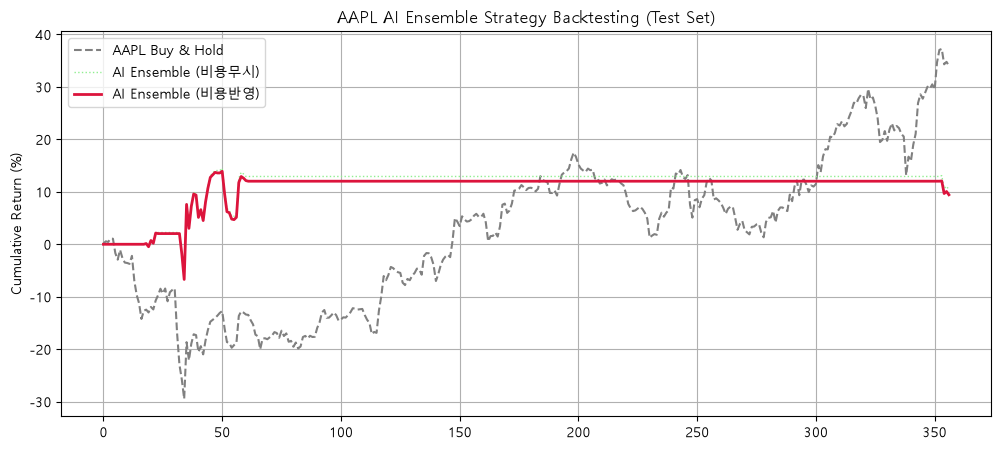

In [79]:
# =====================================================================
# ⚖️ Cell 11 (4단계): Validation AUC 기준 앙상블 가중치 최적화 + 백테스트
# =====================================================================
print('\n⚖️ 4단계: Validation AUC 최대화 가중치 탐색 중 (scipy.optimize)...')

# 1. Validation 세트 예측 확률 추출
lstm_model.eval()
with torch.no_grad():
    lstm_prob_val = lstm_model(torch.tensor(X_vl, dtype=torch.float32).to(device)).cpu().numpy().flatten()
lgbm_prob_val = lgbm_model.predict_proba(X_vl_flat)[:, 1]
rf_prob_val   = rf_model.predict_proba(X_vl_flat)[:, 1]

# 2. Test 세트 예측 확률 추출
with torch.no_grad():
    lstm_prob_test = lstm_model(torch.tensor(X_te, dtype=torch.float32).to(device)).cpu().numpy().flatten()
lgbm_prob_test = lgbm_model.predict_proba(X_te_flat)[:, 1]
rf_prob_test   = rf_model.predict_proba(X_te_flat)[:, 1]

# 3. Validation AUC를 최대화하는 가중치 탐색 (음수 방지 + 합=1 제약)
def neg_val_auc(raw_w):
    w = np.abs(raw_w)
    w = w / (w.sum() + 1e-9)
    ens = w[0]*lstm_prob_val + w[1]*lgbm_prob_val + w[2]*rf_prob_val
    return -roc_auc_score(y_vl, ens)

init_w = np.array([1/3, 1/3, 1/3])
opt_result = minimize(neg_val_auc, init_w, method='Nelder-Mead',
                       options={'xatol': 1e-4, 'fatol': 1e-4, 'maxiter': 500})

opt_w = np.abs(opt_result.x)
opt_w = opt_w / opt_w.sum()
W_LSTM, W_LGBM, W_RF = opt_w

print(f'✅ 최적 가중치 탐색 완료! (Validation AUC 기준 동적 최적화)')
print(f'   W_LSTM={W_LSTM:.3f} | W_LGBM={W_LGBM:.3f} | W_RF={W_RF:.3f}')

val_ens = W_LSTM*lstm_prob_val + W_LGBM*lgbm_prob_val + W_RF*rf_prob_val
val_auc = roc_auc_score(y_vl, val_ens)
val_auc_equal = roc_auc_score(y_vl, (lstm_prob_val + lgbm_prob_val + rf_prob_val) / 3)
print(f'   Validation AUC (최적화 후): {val_auc:.4f}  (균등 가중치였다면: {val_auc_equal:.4f})')

# 4. 최종 Test 세트 결합 및 평가
final_test_ens = W_LSTM*lstm_prob_test + W_LGBM*lgbm_prob_test + W_RF*rf_prob_test
real_test_auc  = roc_auc_score(y_te, final_test_ens)

print("\n" + "="*55)
print(f"        🔥 [최종 검증] 실전 투입 시 예상 성능 🔥")
print("="*55)
print(f"   * 진짜 Test AUC : {real_test_auc:.4f}")
print("="*55)

# 5. meta.pkl에 최적화된 가중치 반영
with open(f'{save_dir}/meta.pkl', 'rb') as f:
    meta = pickle.load(f)
meta['W_LSTM'] = W_LSTM
meta['W_LGBM'] = W_LGBM
meta['W_RF']   = W_RF
with open(f'{save_dir}/meta.pkl', 'wb') as f:
    pickle.dump(meta, f)
print(f'✅ meta.pkl 가중치 갱신 완료! (W_LSTM={W_LSTM:.3f} | W_LGBM={W_LGBM:.3f} | W_RF={W_RF:.3f})')

# =====================================================================
# 📊 성과지표 헬퍼 (#10) — 일별 전략 수익률 → Sharpe/MDD 등
# =====================================================================
def perf_metrics_daily(daily_returns):
    r = np.asarray(daily_returns, dtype=float)
    out = {'cum':0.0,'sharpe':0.0,'sortino':0.0,'mdd':0.0,'calmar':0.0,'winrate':0.0,'n':int(len(r))}
    if len(r) == 0: return out
    out['cum'] = float(np.prod(1+r)-1)
    mean, sd = r.mean(), (r.std(ddof=1) if len(r)>1 else 0.0)
    out['sharpe'] = float(mean/sd*np.sqrt(252)) if sd>0 else 0.0     # 일별 → 연율화
    ds = r[r<0]; dsd = ds.std(ddof=1) if len(ds)>1 else 0.0
    out['sortino'] = float(mean/dsd*np.sqrt(252)) if dsd>0 else 0.0
    eq = np.cumprod(1+r); peak = np.maximum.accumulate(eq)
    out['mdd'] = float(((eq-peak)/peak).min())
    out['calmar'] = float(out['cum']/abs(out['mdd'])) if out['mdd']<0 else 0.0
    nz = r[r!=0]
    out['winrate'] = float((nz>0).mean()) if len(nz)>0 else 0.0
    return out

def print_daily_metrics(name, m):
    print(f'   [{name}] 누적={m["cum"]*100:6.1f}% | Sharpe={m["sharpe"]:5.2f} | '
          f'Sortino={m["sortino"]:5.2f} | MDD={m["mdd"]*100:6.1f}% | '
          f'Calmar={m["calmar"]:5.2f} | 승률(거래일)={m["winrate"]*100:4.1f}% | n={m["n"]}')

# =====================================================================
# 🚀 백테스팅 매매 로직 (숏 금지 + 현금 관망 + 5일 홀딩 + #4 거래비용)
#   ⚠️ #5 참고: 라벨은 'PRED_DAYS일 뒤 방향성'인데 실행은 일별 수익 누적(5일 홀딩)이라
#      학습 타겟과 실행 방식이 완전히 일치하지는 않음(구조적 한계).
# =====================================================================
import matplotlib.pyplot as plt
test_returns = df_feat['Return'].iloc[-len(y_te):].values

strategy_signals = []
current_position = 0
hold_counter = 0
TARGET_THRESHOLD = BEST_THRESHOLD

for i in range(len(final_test_ens)):
    prob = final_test_ens[i]
    if current_position == 1:
        hold_counter -= 1
        if hold_counter == 0:
            current_position = 0
    if current_position == 0:
        if prob > (0.5 + TARGET_THRESHOLD):
            current_position = 1
            hold_counter = HOLDING_DAYS
        else:
            current_position = 0
    strategy_signals.append(current_position)

strategy_signals = np.array(strategy_signals)
shifted_signals = np.insert(strategy_signals[:-1], 0, 0)   # 신호는 다음날 체결

# ✅ #4 거래비용: 포지션이 바뀌는 날(진입/청산)마다 편도 비용 차감
turnover = np.abs(np.diff(shifted_signals, prepend=0))
gross_strategy_returns = shifted_signals * test_returns
strategy_returns       = gross_strategy_returns - turnover * TRANSACTION_COST

cum_market_returns   = np.cumprod(1 + test_returns) - 1
cum_strategy_returns = np.cumprod(1 + strategy_returns) - 1
cum_gross_returns    = np.cumprod(1 + gross_strategy_returns) - 1

# 📊 성과지표 출력 (전략 vs 시장) + 거래비용 영향
m_strat  = perf_metrics_daily(strategy_returns)
m_gross  = perf_metrics_daily(gross_strategy_returns)
m_market = perf_metrics_daily(test_returns)
print('\n📊 백테스트 성과 (Test 구간):')
print_daily_metrics('전략(비용반영)', m_strat)
print_daily_metrics('전략(비용무시)', m_gross)
print_daily_metrics(f'{TICKER} Buy&Hold', m_market)
print(f'   💸 거래횟수(진입+청산)≈{int(turnover.sum())}회 | 비용이 갉아먹은 누적수익: {(m_gross["cum"]-m_strat["cum"])*100:.1f}%p')

# #12 레짐 분해: 시장 상승일/하락일로 나눈 전략 성과
up = test_returns > 0
print('\n📉 레짐별(시장 일간 방향) 전략 성과:')
print_daily_metrics(f'상승일({up.sum()}일)',    perf_metrics_daily(strategy_returns[up]))
print_daily_metrics(f'하락일({(~up).sum()}일)', perf_metrics_daily(strategy_returns[~up]))

line_color = 'forestgreen' if cum_strategy_returns[-1] > cum_market_returns[-1] else 'crimson'
plt.figure(figsize=(12, 5))
plt.plot(cum_market_returns * 100, label=f'{TICKER} Buy & Hold', color='gray', linestyle='--')
plt.plot(cum_gross_returns * 100, label='AI Ensemble (비용무시)', color='lightgreen', linewidth=1, linestyle=':')
plt.plot(cum_strategy_returns * 100, label='AI Ensemble (비용반영)', color=line_color, linewidth=2)
plt.title(f'{TICKER} AI Ensemble Strategy Backtesting (Test Set)')
plt.ylabel('Cumulative Return (%)')
plt.legend()
plt.grid(True)
plt.show()

In [80]:
# =====================================================================
# 🔮 Cell 12: 실전 예측 대시보드 (헤지펀드 실전 가이드 적용)
#   ✅ #1 for_predict=True 로 최신 거래일까지 보존 (기존엔 마지막 PRED_DAYS일이 잘려
#         사실상 며칠 전 데이터로 예측하면서 '오늘 기준'으로 표기하던 버그)
#   ✅ #2 bfill 제거  ·  #7 시그널 강도 100% 상한 클램프
# =====================================================================
def predict_latest_us(ticker=TICKER):
    df_new, nm   = fetch_us_data(ticker, START_DATE, END_DATE)
    df_ext_new   = fetch_external_data(START_DATE, END_DATE)
    df_f         = add_features(
                       df_new.join(df_ext_new, how='left').ffill().dropna(),
                       threshold=BEST_THRESHOLD,
                       for_predict=True                    # ✅ 최신일 보존
                   )
    X_new = np.where(np.isinf(df_f[feature_cols].values), np.nan, df_f[feature_cols].values)
    X_new = pd.DataFrame(X_new, columns=feature_cols).ffill().values   # ✅ bfill 제거
    X_new_sc  = scaler.transform(X_new)
    X_new_sel = selector.transform(X_new_sc)
    seq  = X_new_sel[-SEQ_LEN:][np.newaxis, ...]
    flat = X_new_sel[-1:, :]
    lstm_model.eval()
    with torch.no_grad():
        lp = lstm_model(
            torch.tensor(seq, dtype=torch.float32).to(device)
        ).cpu().numpy()[0][0]
    gp   = lgbm_model.predict_proba(flat)[0][1]
    rp   = rf_model.predict_proba(flat)[0][1]
    prob = W_LSTM*lp + W_LGBM*gp + W_RF*rp

    # -----------------------------------------------------------------
    # 🚀 [업그레이드 세팅] 매매 룰 마진 계산 및 시그널 강도 산출
    # -----------------------------------------------------------------
    TARGET_THRESHOLD = BEST_THRESHOLD
    signal_strength = min(abs(prob - 0.5) * 200, 100.0)   # ✅ #7 100% 상한

    if prob > (0.5 + TARGET_THRESHOLD):
        decision = "🔥 강력 매수 (STRONG LONG)" if signal_strength > 15 else "📈 조건부 매수 (LONG)"
        action_plan = f"오늘 종가에 진입 후 최소 {HOLDING_DAYS}영업일 동안 무조건 홀딩 (잔파도 무시)"
    elif prob < (0.5 - TARGET_THRESHOLD):
        decision = "🚨 위험 감지: 현금 대피 (CASH OUT)"
        action_plan = f"신규 진입 절대 금지 및 기존 포지션 전량 현금화 후 관망"
    else:
        decision = "💤 방향성 불투명: 관망 (HOLD CASH)"
        action_plan = f"매수 마진(Threshold) 미달. 안전하게 현금 100% 쥐고 대기"

    print("\n" + "="*65)
    print(f" 🔮 PyTorch 앙상블 실전 매매 시그널 대시보드: {nm}")
    print("="*65)
    print(f" 📅 기준 거래일  : {df_f.index[-1].strftime('%Y-%m-%d')} (종가: ${df_f['Close'].iloc[-1]:.2f})")
    print(f" 🎯 타겟 예측    : 미래 {PRED_DAYS}영업일 뒤 방향성 (Threshold 마진: {TARGET_THRESHOLD})")
    print(f" 🛡️ 매매 룰 세팅 : 숏(인버스) 절대 금지 | 강제 홀딩 기간: {HOLDING_DAYS}일")
    print("-"*65)
    print(f" [모델 1] PatchTST(TF)   : {lp*100:.1f}% (Opinion: {'📈 BUY' if lp > 0.5 else '📉 CASH'})")
    print(f" [모델 2] LightGBM       : {gp*100:.1f}% (Opinion: {'📈 BUY' if gp > 0.5 else '📉 CASH'})")
    print(f" [모델 3] RandomForest   : {rp*100:.1f}% (Opinion: {'📈 BUY' if rp > 0.5 else '📉 CASH'})")
    print("─"*65)
    print(f" 🏆 앙상블 최종 결론 : {decision}")
    print(f" 📊 시그널 신뢰 강도 : {signal_strength:.1f}% (앙상블 확률: {prob*100:.1f}%)")
    print(f" 🎯 실전 매매 가이드 : {action_plan}")
    print("="*65)
    return prob

prob_final = predict_latest_us(TICKER)

📡 AAPL yfinance 주가 데이터 수집 중...
✅ AAPL 데이터 수집 완료! (2904일치)
📡 글로벌 거시경제 지수 동기화 중...

 🔮 PyTorch 앙상블 실전 매매 시그널 대시보드: AAPL
 📅 기준 거래일  : 2026-07-22 (종가: $325.89)
 🎯 타겟 예측    : 미래 3영업일 뒤 방향성 (Threshold 마진: 0.012)
 🛡️ 매매 룰 세팅 : 숏(인버스) 절대 금지 | 강제 홀딩 기간: 5일
-----------------------------------------------------------------
 [모델 1] PatchTST(TF)   : 53.5% (Opinion: 📈 BUY)
 [모델 2] LightGBM       : 44.4% (Opinion: 📉 CASH)
 [모델 3] RandomForest   : 31.0% (Opinion: 📉 CASH)
─────────────────────────────────────────────────────────────────
 🏆 앙상블 최종 결론 : 🚨 위험 감지: 현금 대피 (CASH OUT)
 📊 시그널 신뢰 강도 : 14.0% (앙상블 확률: 43.0%)
 🎯 실전 매매 가이드 : 신규 진입 절대 금지 및 기존 포지션 전량 현금화 후 관망
